# $Neural-Networks$

## Neuron
- Neuron is a single unit of a neural network
- Multiple neurons combine to form a neural network

![](https://storage.googleapis.com/kaggle-media/learn/images/mfOlDR6.png)
Linear Unit : **y = wx + b**
- 
- Bias - a kind of special weight. This helps activate a neuron independently of a input
- Especially if the input = 0, then bias decides the output

If there are mulitple inputs to deal with:

![](https://storage.googleapis.com/kaggle-media/learn/images/vyXSnlZ.png)

- Let's implement this using a python framework - Tensorflow

In [14]:
# pip install tensorflow

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(units = 1,   # single neuron
    input_shape = [4])        # take single input
])

## **Neural Networks**

- A combination of multiple neuron units into layers
- We can arrange multiple layers of these neurons to form a more complex neural network
- 
![](https://storage.googleapis.com/kaggle-media/learn/images/2MA4iMV.png)

- you can think that each neuron is performing some kind of **data transformation** to the inputs
- **`z` = sum(wi * xi) + b** - this output `z` is linear
- We introduce non-linearity into the system, so that we can identify more complex patterns later
- in a dense layer `z1` and `z2` we are getting linear output
- If there is nothing between them, does adding another dense layer do anything?
- Then Dense layers do nothing - but just addition
- We need activation functions - because without them, our model will only learn linear relationships --- we already have linear regression for that!!!

[Activation Functions](#activation-functions)

- There are three types of layers:
1. **Input Layer**
    - Where the data is fed to the network
    - Generally is not a neuron layer, but a place holder layer to store inputs
    - Define exactly how many features - Dimensionality
    - Must match the number of features in your data
    - Data that enters a network, should be of a similar scale, to prevent the Vanishing Gradient problem (model stops learning becuase the numbers are too large, or too small)
2. **Hidden Layers**
    - Intermediate layers aka Intermediate Representations (IR) 
    - This is where the network performs computations
    - More hidden layers, deeper the network, more complex patterns can be found
    - Non-Linear Activation functions that allow the network to learn non linear patterns
    - 
3. **Ouput Layer**
    - final layer that produces the predictions/outcomes
    - **Binary classification**, we use **1 neuron** as output - with an activation function: **Sigmoid**
    - **Multiclass classification**, we use **multiple neurons** (one per class) - with an activation function: **Softmax**
    - **Regression**, use **1 neuron**, without any activation (linear outputs) because we need a single value

- A neural network in tensorflow

In [16]:
model = keras.Sequential([
    # input definition - in this case we can say that this is an Input Layer
    # there is no computation that happens here
    layers.Input(shape=(4,)),

    # first hidden layer - Type = Dense
    # Dense - Fully connected Layer
    layers.Dense(units = 4, activation= 'relu'),

    # will scale the outputs from previous layer, to keep them near zero
    # this can make training faster
    layers.BatchNormalization(),

    # the coach
    # will randomly shut off 20% neurons during the training
    # NNs tend to overfit a lot --- memorizing the training data
    # dropout forces the NN to not rely on specific neurons for learning
    # prevents overfitting
    layers.Dropout(0.2),

    # Output layer - The decision maker
    layers.Dense(units=3, activation = 'softmax')

])

- Keras as a high level neural network API
- you can access the Tensorflow toolbox with keras
- Keras helps build and architect neural networks, while Tensorflow handles the data flow and optimization

## **Different Types of Neural Networks**

**1. Feedforward Neural Networks (FNN) / Multi Layer Perceptron (MLP)**
- Simplest form of a neural network
- fully connected layers
**2. Convolutional Neural Network (CNN)**
   - Use an operation called Convolution to process grid like data (images)
    - They preserve spatial relationships 
    - And learn from hierarchical features - Edge -> Shape -> Object

**3. Recurrent Neural Networks (RNN):**
   - networks with loops that allow information to persist
    - the ability to retain information
    - They process sequences ---> Time series data, and Text data
    - Examples:
        - Simple RNN - used for short sequences, simple patterns
        - LSTM - used for long sequences, complex patterns
        - GRU - similar to LSTM but simpler - Speech recognition
        - Bidirectional RNN - context from both direction - 

**4. Transformer**
   - networks based on attention mechanisms
    - learn relationships between all the elements
    - use parallel processing 
    - Positional encoding: add sequence order information
    - process all elements parallelly and learn relationships, no recurrence
    - Can implement Transfer Learning: Pretrain once, then fine tune for different tasks
    - Examples:
        - NLP tasks - BERT, GPT for text classification
        - Vision tasks - ViT for image classification
        - 

**5. Autoencoders**
   - trained to reconstruct their input
    - they learn data by compressing and then reconstructing
    - Unsupervised, does not need labels
    - Reconstruction loss as the measure
    - Examples: 
        - Denoising AE - Noise removal
        - Variational AE (VAE) - Generative Modeling - generate new images, or data

**6. Generative Adversarial Networks (GAN)**
   - Two networks (Generator and Discrimnator) trained in competition
    - Generator creates fake data, discrimnator tries to distinguish it from real
    - one creates and another evaluates
    - Examples:
        - Vanilla GAN - used for basic generation, can generate simple images
        - DCGAN - higher quality image generation
        - CycleGAN - image to image translation or style transfer

## **Working of Neural Networks**

1. Build the Network
2. Forward Propagation
3. Caculate the Loss
4. Back Propagation
5. Gradient Decent Optimization
6. Repeat

- Let's implement all these steps on a simple dataset first, then go deeper into understanding all the steps

In [17]:
import warnings
warnings.filterwarnings("ignore")

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers


# Bring in Data
iris = load_iris()
X, y = iris.data[:110], iris.target[:110]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)
# we won't clean or explore data, because we know it is clean, and we know the dataset

In [19]:
# initialize the model
model = keras.Sequential([
    layers.Input(shape=(4,)), # define the input container
    # hidden layer
    layers.Dense(units = 5, activation= "relu"),

    # output layer
    layers.Dense(units = 3, activation= 'softmax')
])

# complie the model
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy', # loss function - because y is integer type
    metrics = ['accuracy']

)

In [20]:
history = model.fit(X_train, y_train, 
          epochs = 10 , # how many repetitions
          verbose = 0,
          # if we want to validate/test our performance
          batch_size = 10, 
          # how many records are taken at once to calculate the losses
          # to update the weights
          # small batch ---> 8 to 16 - Model takes small chunks of data and calculates error, updates weights frequently
          # more computationaly intensive, each epoch takes longer to finish
          # large batch ---> 128 to 512 - Model takes large chunks of data and calculates error, updates weights 
          # faster but can result in lower accuracy

          validation_split = 0.3, # creates an internal Test data set
          # each epoch 70% of data will be used for training - remaining 10% for testing
          # in each epoch, different validation set is chosen
          # cross validation - helpful in generalization --- makes sure, all the data is used for training
)

In [21]:
# training

history = model.fit(X_train, y_train, 
          epochs = 100 ,
          verbose = 0,
          batch_size = 10,
          validation_split = 0.2, 
)

# evaluate 
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Accuracy = {test_accuracy*100:.2f}%')

# predictions
prediction = model.predict(X_test) 
# prediction: SL for iris looked like this: [0,0,1,2,1,0,1,0,2, ... ] ---> compare it with y_test 


y_pred = np.argmax(prediction, axis = 1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9545 - loss: 0.4826
Accuracy = 95.45%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


array([1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0])

In [22]:
for i in range(len(prediction)): print(f"Predicted Class: {np.argmax(prediction[i])} | Actual: {y_test[i]}")

Predicted Class: 1 | Actual: 1
Predicted Class: 0 | Actual: 0
Predicted Class: 0 | Actual: 0
Predicted Class: 1 | Actual: 1
Predicted Class: 1 | Actual: 1
Predicted Class: 1 | Actual: 1
Predicted Class: 0 | Actual: 0
Predicted Class: 0 | Actual: 0
Predicted Class: 1 | Actual: 1
Predicted Class: 0 | Actual: 0
Predicted Class: 1 | Actual: 1
Predicted Class: 1 | Actual: 1
Predicted Class: 0 | Actual: 0
Predicted Class: 1 | Actual: 1
Predicted Class: 0 | Actual: 0
Predicted Class: 1 | Actual: 1
Predicted Class: 1 | Actual: 1
Predicted Class: 1 | Actual: 1
Predicted Class: 1 | Actual: 2
Predicted Class: 0 | Actual: 0
Predicted Class: 0 | Actual: 0
Predicted Class: 0 | Actual: 0


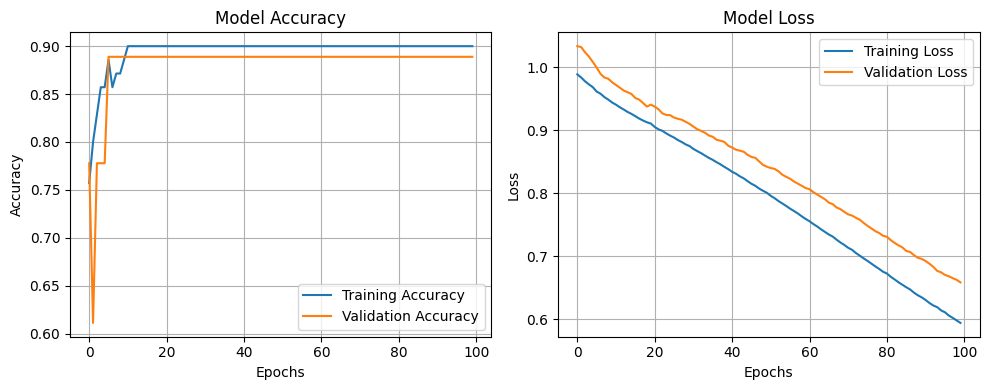

In [23]:
# evaluating, 

history = pd.DataFrame(history.history)
history # accuracy	loss	val_accuracy	val_loss

# Plot Accuracy
plt.figure(figsize=(10, 4))

plt.subplot(1,2,1)
plt.plot(history.accuracy, label = "Training Accuracy")
plt.plot(history.val_accuracy, label = "Validation Accuracy")
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.grid()
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.loss, label = "Training Loss" )
plt.plot(history.val_loss, label = "Validation Loss" )
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

### Thus, we successfully, implemented a Neural Network, to learn from Iris dataset, and make predictions on it, with 95% accuracy

---

## **Working of NNs**
- How we start the process
- what steps we encounter
- and how it all comes together

## **1. Build the Network**
- Initialize the model ---> create the basic architecture of the model
- **Choose number of layers**:
    - **Shallow** (1-2 hidden layers deep) for small datasets - e.g. basic classification
    - **Medium** (3-5 layers) for real world problems - e.g. image classification, sentiment analysis
    - **Deep** (10+ layers) for complex patterns e.g.facial recognition, language modeling etc
    - **Very Deep** (50+ layers) for massive datasets, research e.g. ResNet-152, GPT-3
    - 
- **Choose number of Neurons**:
    - Power of 2 - 8, 16, 32, 128 etc - When GPU optimization
    - Geometric - decrease/increase - i.e. decrease half each next layer/ double each layer
    - Bootleneck - small middle layer - help in dimensionality reduction
    - Generally, in a layer, start with a few neurons (simple model)
    - increase the number of neurons, if the model is underfitting (not learning enough)
    - 


#### **Layers Types**

 Type  | Function  | Usage
------|---|---- 
**Dense** (Fully connected) | every neuron connects to all next layer neurons | General purpose or final layers
**Convolutional** (Conv2D) | Slide filters across spatial data (multidimension) | Images, video, or grid like data
**Recurrent** (LSTM/GRU) | Maintain an internal state across time | Text, time series, sequence type data
**Embedding** | Maps discrete value to continous vectors | Words, categories
**Dropout** | Randomly turn off neurons during the training | Prevent overfitting, or memorization on training data
**Batch Normalization** | normalize outputs, bring them closer to zero | stablize training, for faster convergence (loss isthe minimum)
**Pooling** | Downsample spatial data | reduces dimensions
**Attention** | focus on relevant parts of the input | Transformers, NLP, etc
**Residual** | Adds input to output | very deep networks


#### **Activation Functions**
- Functions that add non linearity to our models

name | function | use
------|---|------
Sigmoid | Logistic Function - squashes any input value into a smooth S curve between 0 to 1 | Binary Classification
Softmax | takes a vector, turns it into a probability distribution | used for multiclass classification, used in output layers
ReLU | Default Choice - gives back z if z > 0 else 0 | fast and helps model learn efficienly
LeakyReLU | | when neurons die or give 0
Tanh | Hyperbolic Tangent - sigmoid but zero-centered - range between -1 to 1 | ocassionally used in hidden layers of RNNs when you want data to be centred around 0
ELU | | 
SELU |  |


##### **ReLU**:
- Let's rectify a linear unit 
- Rectification - operation in electronics - only pass current from one side - i.e. block out the negative current
- this is an activation function in NNs called ReLU
- Input x is positive, ReLU return x, if input is negative it returns 0
- Maths: 
$$f(x) = \max(0, x)$$
- or:

$$f(x) = 
\begin{cases} 
0 & x \le 0 \\
x & x > 0 
\end{cases}$$

![](https://storage.googleapis.com/kaggle-media/learn/images/eFry7Yu.png)

##### **Sigmoid**:
- 

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

##### **Tanh**:
- 
$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

##### **Softmax**:
- 

In [24]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

np.exp(1) # e^1

np.float64(2.718281828459045)

<function matplotlib.pyplot.show(close=None, block=None)>

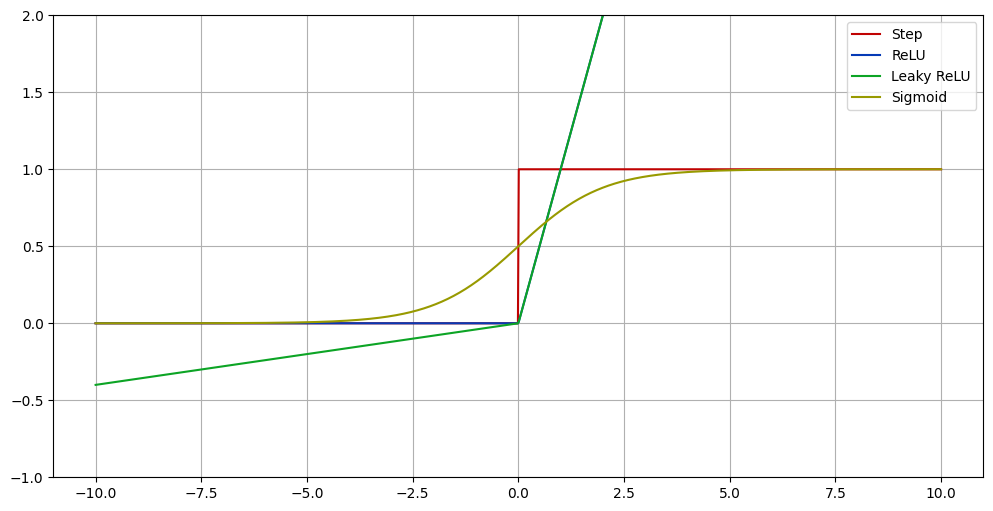

In [25]:
# ReLU function

# step function
def step(z):
    return np.where(z >= 0, 1, 0) # where z >= 0, return z, else return 0
    
# ReLu function
def relu(z):
    return np.where(z >= 0, z, 0) # where z >= 0, return z, else return 0

# ReLu function
def leaky_relu(z, alpha = 0.04):
    return np.where(z >= 0, z, alpha * z) # where z >= 0, return z, else return 0

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


x = np.linspace(-10,10,1000)


plt.figure(figsize=(12,6))
plt.plot(x, step(x), color = "#C00202", label = 'Step' )
plt.plot(x, relu(x), color = "#053AB6", label = 'ReLU' )
plt.plot(x, leaky_relu(x), color = "#0CA425", label = 'Leaky ReLU' )
plt.plot(x, sigmoid(x), color = "#989A00", label = 'Sigmoid' )

plt.ylim(-1, 2)
plt.legend()
plt.grid()
plt.show

- Compile the model:
    - To configure model settings
    - Optimizer - which optimizer to use
    - Loss - What loss function to use
    - metrics - which evaluation metric to use